In [121]:
import pandas as pd 
import geopandas as gpd 
import datetime as dt

df = pd.read_csv("./data/probe-results.csv")

In [122]:
# filter to perim only 
df = df[df.collection_id == "public.eis_fire_lf_perimeter_nrt"]

# get first seen probe time for each timestep
df.probe_time = pd.to_datetime(df.probe_time)
df.newest_feature_datetime = pd.to_datetime(df.newest_feature_datetime)
df = df.sort_values(by="probe_time")
df = df.drop_duplicates(subset=["newest_feature_datetime"])

# Only test AM timesteps because PM runs are mostly failing. These are from N(ight) detections
# due to known GitHub Actions issue 
# filter to only AM 
df = df[df.newest_feature_datetime.dt.hour == 0]

df["first_available_edt"] = df.probe_time - pd.Timedelta(hours=4)
df["first_available_pdt"] = df.probe_time - pd.Timedelta(hours=7)



download FIRMS data for this time range from https://firms.modaps.eosdis.nasa.gov/active_fire/ 

I just grabbed the CONUS/Hawaii 7 day file 


In [123]:

# filter to only CONUS 
pix = pd.read_csv("./data/J1_VIIRS_C2_USA_contiguous_and_Hawaii_7d.csv")

pix = gpd.GeoDataFrame(pix, geometry=gpd.points_from_xy(x=pix["longitude"], y=pix["latitude"]), crs=4326)

# filter out Hawaii (cut everything past -126 deg lon)
pix = pix.cx[-126:, :]

pix["acq_datetime"] = pd.to_datetime(pix.acq_date.astype(str) + " " + pix.acq_time.astype(str).apply(str.zfill, args=[4]))
pix["acq_datetime"] = pix.acq_datetime.dt.tz_localize("UTC")

# we are only looking at the AM timestep right now because the PM timestep is broken anyways. 
# so, filter to only Night detections (~01:30) 
pix = pix.sort_values(by="acq_time", ascending=False) 
pix = pix[pix.daynight == "N"]


Text(0.5, 1.0, 'NOAA20 nighttime overpass times (HHMM, UTC)')

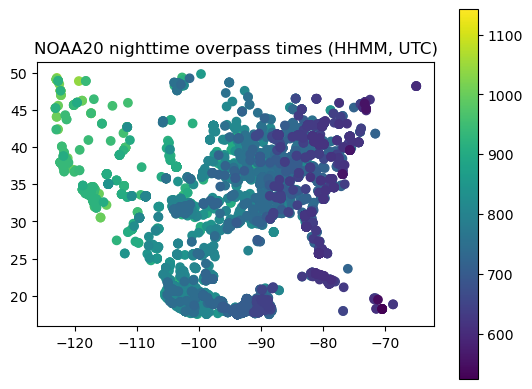

In [124]:
ax = pix.plot(column="acq_time", legend=True)
ax.set_title("NOAA20 nighttime overpass times (HHMM, UTC)")

In [ ]:
# filter to just the last detection in each timestep 
last = pix.sort_values(by="acq_time", ascending=False).drop_duplicates(subset="acq_date").copy() 
last.acq_date = pd.to_datetime(last.acq_date)

# disregard today because it is still morning 
last = last[last.acq_date.dt.date < dt.datetime.now().date()]



In [ ]:
last = last.set_index("acq_date")
df = df.set_index("newest_feature_datetime")

In [ ]:
joined = df.join(last, how="left")
joined["latency"] =  joined["probe_time"] - joined["acq_datetime"]
stats = joined[["probe_time", "acq_datetime", "latency", "first_available_edt", "first_available_pdt"]]
# drop the 28th because I manually triggered it way earlier than the schedule 
# (and the FEDS output is missing west coast data because of that)
stats = stats.drop(pd.to_datetime("2026-04-28"))

In [109]:
stats.latency.describe()

count                         5
mean     0 days 07:03:23.400000
std      0 days 01:46:33.074244
min             0 days 06:09:01
25%             0 days 06:16:02
50%             0 days 06:18:01
75%             0 days 06:20:02
max             0 days 10:13:51
Name: latency, dtype: object

In [ ]:
stats[pd.to_datetime("2026-04-20"):]

,probe_time,acq_datetime,latency,first_available_edt,first_available_pdt
newest_feature_datetime,,,,,
2026-04-23,2026-04-23 19:56:51+00:00,2026-04-23 09:43:00+00:00,0 days 10:13:51,2026-04-23 15:56:51+00:00,2026-04-23 12:56:51+00:00
2026-04-24,2026-04-24 17:20:02+00:00,2026-04-24 11:00:00+00:00,0 days 06:20:02,2026-04-24 13:20:02+00:00,2026-04-24 10:20:02+00:00
2026-04-25,2026-04-25 16:50:01+00:00,2026-04-25 10:41:00+00:00,0 days 06:09:01,2026-04-25 12:50:01+00:00,2026-04-25 09:50:01+00:00
2026-04-26,2026-04-26 16:40:02+00:00,2026-04-26 10:24:00+00:00,0 days 06:16:02,2026-04-26 12:40:02+00:00,2026-04-26 09:40:02+00:00
2026-04-27,2026-04-27 18:00:01+00:00,2026-04-27 11:42:00+00:00,0 days 06:18:01,2026-04-27 14:00:01+00:00,2026-04-27 11:00:01+00:00
